# Models: Linear Regression + Evaluation

### Preperation

##### Importing essential libraries

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##### Data

In [31]:
# Storing data in df
df = pd.read_csv("../data/volvo_2020_2024_clean.csv")


# Check
df.head()

,Date,Close,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_4,Return_Lag_5,MA5
0,2020-01-10,106.104263,-0.004783,-0.016928,0.005992,0.008588,-0.022084,107.171765
1,2020-01-13,105.934288,-0.001602,-0.004783,-0.016928,0.005992,0.008588,106.981384
2,2020-01-14,106.410225,0.004493,-0.001602,-0.004783,-0.016928,0.005992,106.702608
3,2020-01-15,106.002266,-0.003834,0.004493,-0.001602,-0.004783,-0.016928,106.213054
4,2020-01-16,106.852196,0.008018,-0.003834,0.004493,-0.001602,-0.004783,106.260648


### Calculate coefficients

##### Splitting train and test data

In [32]:
# 80% of data for training, 20% for testing
train_size = int(len(df)*0.8)

# Independent Variables with Date
X = df[["Date","Return_Lag_1","Return_Lag_2","Return_Lag_3","Return_Lag_4","Return_Lag_5","MA5"]]
# Dependent Variable Close with Date shifted by -1 because we want to predict the next day's Close
Y = df[["Date", "Close"]].shift(-1).dropna()

# Splitting X in X_train and X_test with train_size
X_train,X_test = X.loc[:train_size],X.loc[train_size:]
# Splitting Y in Y_train and Y_test with train_size
Y_train,Y_test = Y.loc[:train_size],Y.loc[train_size:]


# Check
X_test.tail()


,Date,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_4,Return_Lag_5,MA5
1250,2024-12-19,-0.020682,-0.000363,0.002910,-0.019615,-0.009187,257.864023
1251,2024-12-20,-0.008151,-0.020682,-0.000363,0.002910,-0.019615,255.484894
1252,2024-12-23,-0.005603,-0.008151,-0.020682,-0.000363,0.002910,253.855099
1253,2024-12-27,0.008264,-0.005603,-0.008151,-0.020682,-0.000363,252.487564
1254,2024-12-30,0.000745,0.008264,-0.005603,-0.008151,-0.020682,251.176233


##### Adding y-intercept variable to X_train and removing date from both training DataFrames

In [33]:
# Adding column of 1:s
X_train.insert(0,"y-intercept",1)

# Removing Date colum from X_train
X_train = X_train.drop(columns=["Date"])

# Removing date column from Y_train
Y_train = Y_train.drop(columns=["Date"])

# Check
X_train.head()

,y-intercept,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_4,Return_Lag_5,MA5
0,1,-0.004783,-0.016928,0.005992,0.008588,-0.022084,107.171765
1,1,-0.001602,-0.004783,-0.016928,0.005992,0.008588,106.981384
2,1,0.004493,-0.001602,-0.004783,-0.016928,0.005992,106.702608
3,1,-0.003834,0.004493,-0.001602,-0.004783,-0.016928,106.213054
4,1,0.008018,-0.003834,0.004493,-0.001602,-0.004783,106.260648


##### Turing training DataFrames into numpy arrays

In [34]:
# Convert from pandas dataframe into numpy array
X_train_np = X_train.to_numpy()
Y_train_np = Y_train.to_numpy()

#Check
print(X_train_np)

[[ 1.00000000e+00 -4.78326394e-03 -1.69276829e-02 ...  8.58778224e-03
  -2.20839965e-02  1.07171765e+02]
 [ 1.00000000e+00 -1.60196467e-03 -4.78326394e-03 ...  5.99167734e-03
   8.58778224e-03  1.06981384e+02]
 [ 1.00000000e+00  4.49275583e-03 -1.60196467e-03 ... -1.69276829e-02
   5.99167734e-03  1.06702608e+02]
 ...
 [ 1.00000000e+00 -1.33641799e-03  8.27720496e-03 ... -6.88473240e-03
   6.73856293e-03  2.30505911e+02]
 [ 1.00000000e+00  5.73601913e-04 -1.33641799e-03 ...  3.85133002e-04
  -6.88473240e-03  2.30550095e+02]
 [ 1.00000000e+00 -5.54071601e-03  5.73601913e-04 ...  8.27720496e-03
   3.85133002e-04  2.30656134e+02]]


##### Linear regression using matrix formula

In [35]:
# Transpose X_train
X_transpose = X_train_np.transpose()

# X_transpose * X_train
Xt_X = X_transpose@X_train_np

# Inverse Xt_X
Xt_X_inv = np.linalg.inv(Xt_X)

# Calculate B 
B = Xt_X_inv@X_transpose@Y_train_np 

# Show coefficients B0 - B6 where B0 = y-intercept, B1 - B5 are coefficients for Return_Lag_1-5
# and B6 is the coefficient for MA5
print(B)


[[-0.23822054]
 [97.56908109]
 [72.57731198]
 [46.51889809]
 [28.15956697]
 [ 2.00245508]
 [ 1.00249411]]


### Calculating and plotting prediction

##### Calculating prediction

In [36]:
# Adding Columns Close_Predict based on the coefficients in B
X_test["Close_Predict"] = B[0] + B[1]*X_test["Return_Lag_1"] + B[2]*X_test["Return_Lag_2"] + B[3]*X_test["Return_Lag_3"] + B[4]*X_test["Return_Lag_4"] + B[5]*X_test["Return_Lag_5"] + B[6]*X_test["MA5"]

X_test.head()


C:\Users\Gymnasiet\AppData\Local\Temp\ipykernel_19660\278273855.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["Close_Predict"] = B[0] + B[1]*X_test["Return_Lag_1"] + B[2]*X_test["Return_Lag_2"] + B[3]*X_test["Return_Lag_3"] + B[4]*X_test["Return_Lag_4"] + B[5]*X_test["Return_Lag_5"] + B[6]*X_test["MA5"]


,Date,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_4,Return_Lag_5,MA5,Close_Predict
1004,2024-01-02,-0.005541,0.000574,-0.001336,0.008277,0.000385,230.656134,230.665909
1005,2024-01-03,-0.018444,-0.005541,0.000574,-0.001336,0.008277,229.896207,228.035321
1006,2024-01-04,-0.020748,-0.018444,-0.005541,0.000574,-0.001336,227.819656,224.542433
1007,2024-01-05,-0.009994,-0.020748,-0.018444,-0.005541,0.000574,225.363141,222.193215
1008,2024-01-08,0.009489,-0.009994,-0.020748,-0.018444,-0.005541,223.295422,222.319012


In [ ]:
Y_pred = B[0] + B[1]*X_test["Return_Lag_1"] + B[2]*X_test["Return_Lag_2"] + B[3]*X_test["Return_Lag_3"] + B[4]*X_test["Return_Lag_4"] + B[5]*X_test["Return_Lag_5"] + B[6]*X_test["MA5"]

Y_pred.head()

##### Setting date as index 

In [37]:
# Adding date as a column
X_test["Date_Predict"] = X_test["Date"].shift(-1)

# Removing the last row with NaN value
X_test.dropna(inplace=True)

# Setting the date as index
X_test.set_index("Date", inplace=True)
Y_test.set_index("Date", inplace=True)

# Turing the index into the datatype datetime
X_test.index = pd.to_datetime(X_test.index)
Y_test.index = pd.to_datetime(Y_test.index)

#Check
print(X_test.tail(),"\n", Y_test.tail())



            Return_Lag_1  Return_Lag_2  Return_Lag_3  Return_Lag_4  \
Date                                                                 
2024-12-18     -0.000363      0.002910     -0.019615     -0.009187   
2024-12-19     -0.020682     -0.000363      0.002910     -0.019615   
2024-12-20     -0.008151     -0.020682     -0.000363      0.002910   
2024-12-23     -0.005603     -0.008151     -0.020682     -0.000363   
2024-12-27      0.008264     -0.005603     -0.008151     -0.020682   

            Return_Lag_5         MA5  Close_Predict Date_Predict  
Date                                                              
2024-12-18     -0.003521  260.318091     259.726730   2024-12-19  
2024-12-19     -0.009187  257.864023     255.789309   2024-12-20  
2024-12-20     -0.019615  255.484894     253.613328   2024-12-23  
2024-12-23      0.002910  253.855099     252.145231   2024-12-27  
2024-12-27     -0.000363  252.487564     252.316450   2024-12-30   
                  Close
Date           

C:\Users\Gymnasiet\AppData\Local\Temp\ipykernel_19660\2145459503.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["Date_Predict"] = X_test["Date"].shift(-1)
C:\Users\Gymnasiet\AppData\Local\Temp\ipykernel_19660\2145459503.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.dropna(inplace=True)


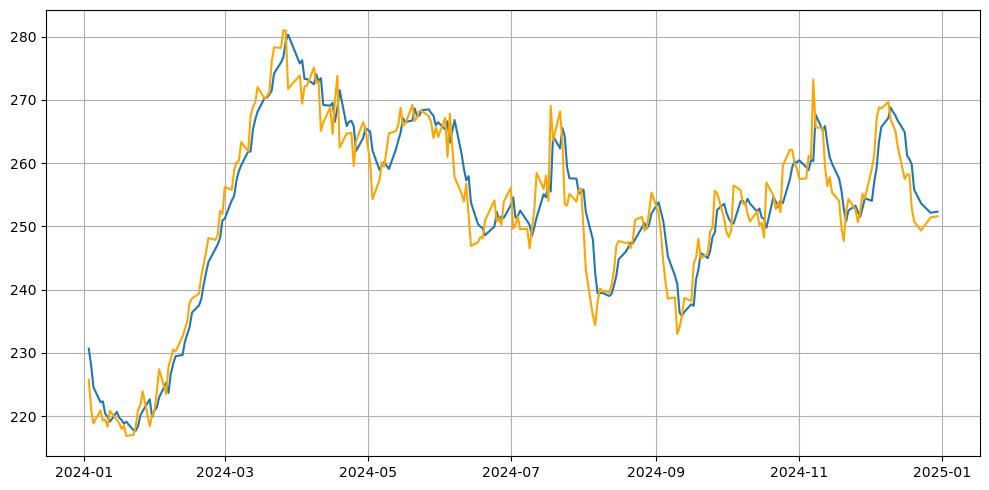

In [38]:
plt.figure(figsize=(10,5))
plt.plot(Y_test.index, X_test["Close_Predict"])
plt.plot(Y_test.index,Y_test, color="orange")
plt.grid(True)
plt.tight_layout()
plt.show()

### Naive Yesterday = Today Model

##### Making model

In [39]:
# Shift Close one day to create Naive Forecast
df["Naive_Close"] = df["Close"].shift(1)

# Creating Naive Test DataFrame
naive_test = df[["Date","Naive_Close"]].loc[train_size:]

# Removing first row to make the length of Naive Test the same as Y_test
naive_test.drop(naive_test.index[0], inplace=True)

# Check
naive_test.head()



,Date,Naive_Close
1005,2024-01-03,229.966904
1006,2024-01-04,225.725433
1007,2024-01-05,221.042145
1008,2024-01-08,218.833038
1009,2024-01-09,220.909592


##### Setting Date as index

In [40]:
# Setting the date as index
naive_test.set_index("Date", inplace=True)

# Turing the index into the datatype datetime
naive_test.index = pd.to_datetime(naive_test.index)

#Check
naive_test.head()

,Naive_Close
Date,
2024-01-03,229.966904
2024-01-04,225.725433
2024-01-05,221.042145
2024-01-08,218.833038
2024-01-09,220.909592


##### Plotting  close, linear regression prediction and naive prediciton

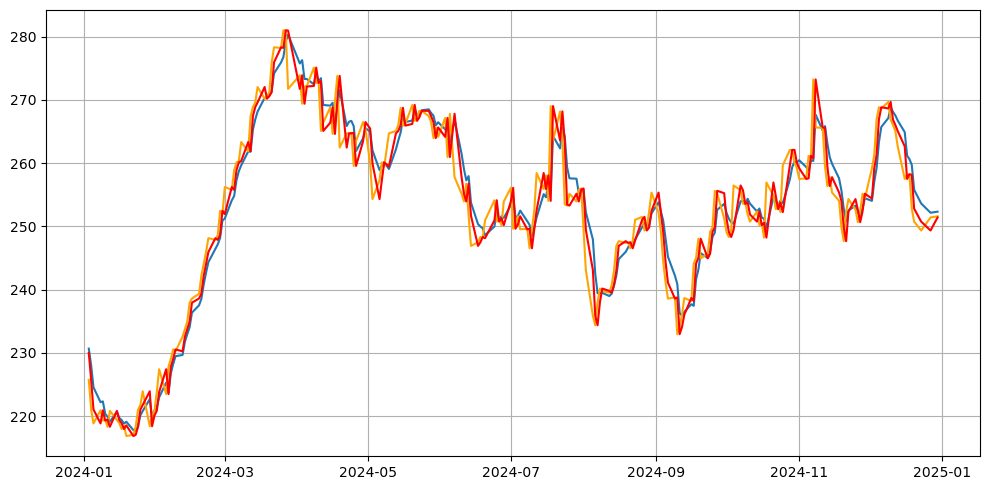

In [41]:
plt.figure(figsize=(10,5))
plt.plot(Y_test.index, X_test["Close_Predict"])
plt.plot(Y_test.index,Y_test, color="orange")
plt.plot(Y_test.index,naive_test, color="red")
plt.grid(True)
plt.tight_layout()
plt.show()

### Calculating RMSE and MAPE

##### Checking alignment between dataframes

In [42]:
print("Length of X_test:", len(X_test))
print("Length of Y_test:", len(Y_test))
print("Length of naive_test:", len(naive_test))

Length of X_test: 250
Length of Y_test: 250
Length of naive_test: 250


In [51]:
print(X_test[["Date_Predict","Close_Predict"]].tail(),"\n", Y_test.tail(), "\n", naive_test.tail())

           Date_Predict  Close_Predict
Date                                  
2024-12-18   2024-12-19     259.726730
2024-12-19   2024-12-20     255.789309
2024-12-20   2024-12-23     253.613328
2024-12-23   2024-12-27     252.145231
2024-12-27   2024-12-30     252.316450 
                  Close
Date                  
2024-12-19  252.806015
2024-12-20  250.745377
2024-12-23  249.340378
2024-12-27  251.401031
2024-12-30  251.588364 
             Naive_Close
Date                   
2024-12-19   258.145020
2024-12-20   252.806015
2024-12-23   250.745377
2024-12-27   249.340378
2024-12-30   251.401031


##### Calculating RMSE (Root mean square error)

In [44]:
# Calculate RMSE for linear regression model
rmse_lr = np.sqrt(np.mean((X_test["Close_Predict"] - Y_test["Close"])**2))
# Calculate RMSE for naive model
rmse_naive = np.sqrt(np.mean((naive_test["Naive_Close"] - Y_test["Close"])**2))
print("RMSE for Linear Regression Model:", rmse_lr)
print("RMSE for Naive Model:", rmse_naive)

RMSE for Linear Regression Model: 1.9409172996723554
RMSE for Naive Model: 3.4436319953495333


##### Calculating MAPE (Mean absolute percentage error)

In [ ]:
# Calculate MAPE for linear regression model
mape_lr = np.mean(np.abs((Y_test["Close"] - X_test["Close_Predict"]) / Y_test["Close"])) * 100
# Calculate MAPE for naive model
mape_naive = np.mean(np.abs((Y_test["Close"] - naive_test["Naive_Close"]) / Y_test["Close"])) * 100
print("MAPE for Linear Regression Model:", mape_lr)
print("MAPE for Naive Model:", mape_naive)

MAPE for Linear Regression Model: 0.6042402443675015
MAPE for Naive Model: 1.0098779729068963


: 